In [1]:
import torch
import matplotlib.pyplot as plt
import math

# 1D Viscous Burgers Equation with PyTorch

We solve the one-dimensional viscous Burgers equation

$$
\partial_t u + u\partial_x u = \nu \partial_{xx}u
$$

on the spatial domain

$$
-1 < x < 1
$$

with zero boundary conditions

$$u(t,-1)=0, \qquad u(t,1)=0
$$

and initial condition

$$u(0,x) = -\sin(\pi x).
$$

Unlike the heat equation example, we do **not** use an exact solution here.
The goal is to solve the PDE numerically using the finite difference method (FDM).

In this notebook, we compare two approximations for the nonlinear convection term:

1. **Upwind difference** for $u_x$,
2. **Central difference** for $u_x$.

This comparison is useful because central difference can be less stable for convection-dominated nonlinear PDEs.

## Configuration of grid and time

We discretize the spatial domain and choose a time step using simple explicit-method stability guidelines:

$$
\frac{\max |u|\Delta t}{\Delta x} \leq C, \qquad
\frac{\nu\Delta t}{\Delta x^2} \leq \frac{1}{2}.
$$

The first condition controls the nonlinear convection term, and the second condition controls the diffusion term.

These conditions are only rough guidelines for the nonlinear Burgers equation, especially when central difference is used for the convection term.

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# viscosity
viscosity = 0.01 / math.pi

# domain and final time
x_min = -1.0
x_max =  1.0
T     = 1.0

# spatial grid
Nx = 201
dx = (x_max - x_min) / (Nx - 1)
x  = torch.linspace(x_min, x_max, Nx, device=device)

# initial condition, used only for choosing a safe time step
u0 = -torch.sin(torch.pi * x)
u0[0]  = 0.0
u0[-1] = 0.0

max_speed0 = torch.max(torch.abs(u0)).item()

# simple stability parameters
CFL = 0.4
r_target = 0.4

dt_convection = CFL * dx / max_speed0
dt_diffusion  = r_target * dx**2 / viscosity

dt_raw = min(dt_convection, dt_diffusion)
Nt = math.ceil(T / dt_raw)
dt = T / Nt

r = viscosity * dt / dx**2
cfl_number = max_speed0 * dt / dx

print("device:", device)
print("viscosity =", viscosity)
print("dx =", dx)
print("dt =", dt)
print("Nt =", Nt)
print("CFL number =", cfl_number)
print("r = viscosity*dt/dx^2 =", r)

# set x_grid for plotting
x_cpu = x.detach().cpu().numpy()

device: cuda
viscosity = 0.003183098861837907
dx = 0.01
dt = 0.004
Nt = 250
CFL number = 0.4
r = viscosity*dt/dx^2 = 0.12732395447351627


# FDM Update Rules for the 1D Burgers Equation

The 1D viscous Burgers equation is

$$
\partial_t u + u\partial_x u = \nu \partial_{xx}u.
$$

Equivalently,

$$
\partial_t u = -u\partial_x u + \nu \partial_{xx}u.
$$

For the time derivative, we use forward Euler:

$$
\partial_t u \approx \frac{u_i^{n+1}-u_i^n}{\Delta t}.
$$

For the diffusion term, both methods use the centered second difference:

$$
\partial_{xx}u_i^n
\approx
\frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}.
$$

## 1. Upwind difference for the nonlinear convection term

For the nonlinear convection term, we can use an upwind difference:

$$
D_x^{\mathrm{up}}u_i^n
=
\begin{cases}
\dfrac{u_i^n-u_{i-1}^n}{\Delta x}, & u_i^n \geq 0, \\
\dfrac{u_{i+1}^n-u_i^n}{\Delta x}, & u_i^n < 0.
\end{cases}
$$

Then the update rule is

$$u_i^{n+1}
= u_i^n
-
\Delta t\,u_i^nD_x^{\mathrm{up}}u_i^n
+
\nu\Delta t
\frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}.
$$

## 2. Central difference for the nonlinear convection term

Alternatively, we can use central difference:

$$
D_x^{\mathrm{cen}}u_i^n
=
\frac{u_{i+1}^n-u_{i-1}^n}{2\Delta x}.
$$

Then the update rule is

$$u_i^{n+1}
= u_i^n
-
\Delta t\,u_i^nD_x^{\mathrm{cen}}u_i^n
+
\nu\Delta t
\frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}.
$$

The central-difference scheme is easier to write, but it can produce oscillations or instability near steep gradients.

## Initial condition

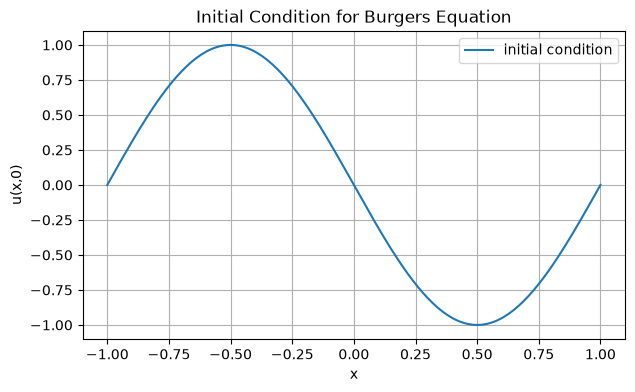

In [4]:
# initial condition
u_initial = -torch.sin(torch.pi * x)

# boundary conditions: u(t,-1)=u(t,1)=0
u_initial[0]  = 0.0
u_initial[-1] = 0.0

plt.figure(figsize=(7, 4))
plt.plot(x_cpu, u_initial.detach().cpu().numpy(), label="initial condition")
plt.xlabel("x")
plt.ylabel("u(x,0)")
plt.title("Initial Condition for Burgers Equation")
plt.legend()
plt.grid(True)
plt.show()

# Solver function

The following function solves Burgers equation by explicit FDM.

The argument `method` controls the approximation of $u_x$:

- `method="upwind"` uses upwind difference,
- `method="central"` uses central difference.

For the central-difference method, we also include a simple blow-up check because the scheme may become unstable for this nonlinear convection problem.

In [5]:
def solve_burgers(method="upwind", blowup_limit=50.0):
    """Solve 1D viscous Burgers equation by explicit FDM."""

    # reset initial condition
    u = -torch.sin(torch.pi * x)
    u[0]  = 0.0
    u[-1] = 0.0

    # store selected solution snapshots
    u_history = []
    t_history = []

    # store more snapshots for the heat-map style visualization
    u_map_history = []
    t_map_history = []

    num_snapshots = 6
    save_steps = sorted(set(int(round(s)) for s in torch.linspace(0, Nt, num_snapshots).tolist()))
    map_save_every = max(1, Nt // 200)

    stopped_early = False
    stop_step = Nt
    stop_reason = "completed"

    for n in range(Nt + 1):

        # current time
        t_now = n * dt

        # save selected snapshots
        if n in save_steps:
            u_history.append(u.detach().cpu().clone())
            t_history.append(t_now)

        # save for heat-map style plot
        if n % map_save_every == 0 or n == Nt:
            u_map_history.append(u.detach().cpu().clone())
            t_map_history.append(t_now)

        # no update after final time
        if n == Nt:
            break

        # copy current solution
        u_old = u.clone()

        # interior values
        u_center = u_old[1:-1]

        # centered second derivative for diffusion
        u_xx = (u_old[2:] - 2.0 * u_old[1:-1] + u_old[:-2]) / dx**2

        # first derivative for nonlinear convection
        if method == "upwind":
            u_x_backward = (u_old[1:-1] - u_old[:-2]) / dx
            u_x_forward  = (u_old[2:]   - u_old[1:-1]) / dx
            u_x = torch.where(u_center >= 0.0, u_x_backward, u_x_forward)

        elif method == "central":
            u_x = (u_old[2:] - u_old[:-2]) / (2.0 * dx)

        else:
            raise ValueError("method must be either 'upwind' or 'central'")

        # explicit update
        u[1:-1] = (
            u_old[1:-1]
            - dt * u_center * u_x
            + viscosity * dt * u_xx
        )

        # boundary conditions
        u[0]  = 0.0
        u[-1] = 0.0

        # simple instability check
        max_abs_u = torch.max(torch.abs(u)).item()
        if torch.isnan(u).any() or max_abs_u > blowup_limit:
            stopped_early = True
            stop_step = n + 1
            stop_reason = f"stopped early because max(|u|) = {max_abs_u:.2f}"
            break

    return {
        "method": method,
        "u_history": u_history,
        "t_history": t_history,
        "u_map_history": u_map_history,
        "t_map_history": t_map_history,
        "stopped_early": stopped_early,
        "stop_step": stop_step,
        "stop_time": stop_step * dt,
        "stop_reason": stop_reason,
    }

# Run both simulations

In [6]:
upwind_result = solve_burgers(method="upwind")
central_result = solve_burgers(method="central")

print("Upwind result:", upwind_result["stop_reason"])
print("Central result:", central_result["stop_reason"])
print("Central stop time:", central_result["stop_time"])

Upwind result: completed
Central result: stopped early because max(|u|) = 271.05
Central stop time: 0.904


# Plot selected snapshots separately

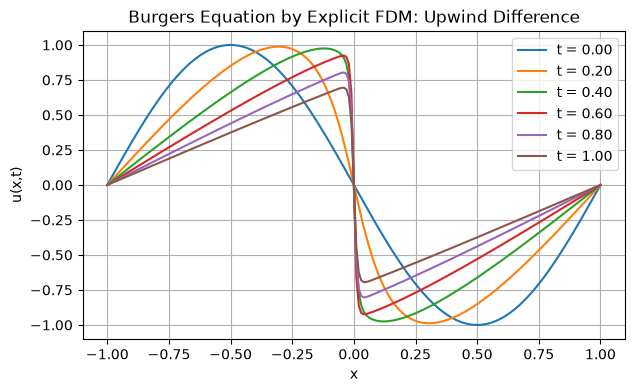

In [7]:
# -----------------------
# Plot selected snapshots: Upwind
# -----------------------

plt.figure(figsize=(7, 4))

for t_now, u_snapshot in zip(upwind_result["t_history"], upwind_result["u_history"]):
    plt.plot(
        x_cpu,
        u_snapshot.numpy(),
        label=f"t = {t_now:.2f}",
    )

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Burgers Equation by Explicit FDM: Upwind Difference")
plt.legend()
plt.grid(True)
plt.show()

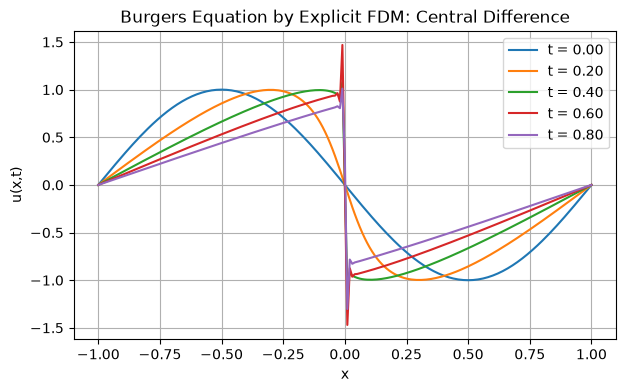

Central difference did not reach T = 1.0
stopped early because max(|u|) = 271.05
Stopped at t = 0.904


In [8]:
# -----------------------
# Plot selected snapshots: Central difference
# -----------------------

plt.figure(figsize=(7, 4))

for t_now, u_snapshot in zip(central_result["t_history"], central_result["u_history"]):
    plt.plot(
        x_cpu,
        u_snapshot.numpy(),
        label=f"t = {t_now:.2f}",
    )

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Burgers Equation by Explicit FDM: Central Difference")
plt.legend()
plt.grid(True)
plt.show()

if central_result["stopped_early"]:
    print("Central difference did not reach T =", T)
    print(central_result["stop_reason"])
    print("Stopped at t =", central_result["stop_time"])

# Compare upwind and central difference using subplots

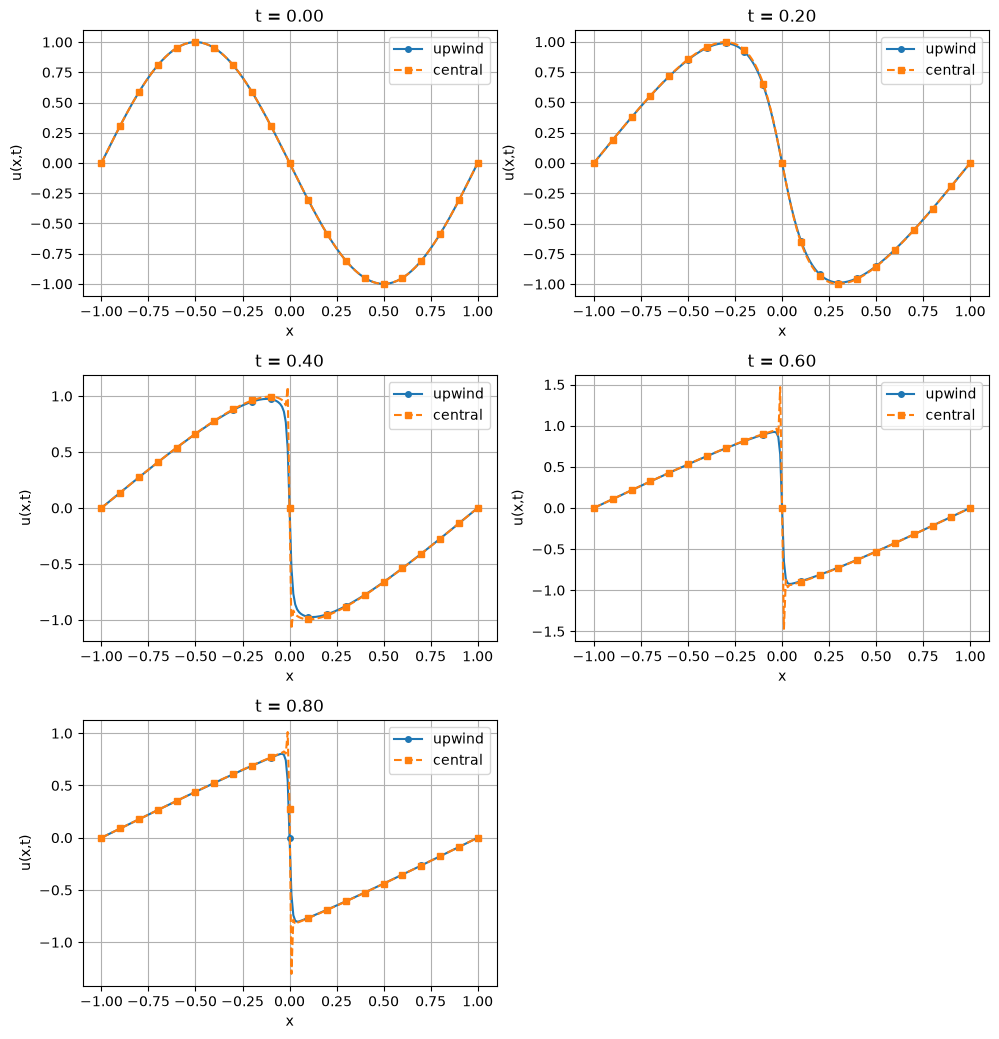

In [9]:
# -----------------------
# Compare upwind and central difference at common saved times
# -----------------------

common_times = sorted(set(upwind_result["t_history"]).intersection(set(central_result["t_history"])))

# map time to snapshot
upwind_dict = dict(zip(upwind_result["t_history"], upwind_result["u_history"]))
central_dict = dict(zip(central_result["t_history"], central_result["u_history"]))

num_plots = len(common_times)
ncols = 2
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.5 * nrows))
if num_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for k, t_now in enumerate(common_times):

    ax = axes[k]

    ax.plot(
        x_cpu,
        upwind_dict[t_now].numpy(),
        "-o",
        markevery=10,
        markersize=4,
        label="upwind",
    )

    ax.plot(
        x_cpu,
        central_dict[t_now].numpy(),
        "--s",
        markevery=10,
        markersize=4,
        label="central",
    )

    ax.set_title(f"t = {t_now:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("u(x,t)")
    ax.grid(True)
    ax.legend()

# hide unused subplot axes
for j in range(num_plots, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# Heat-map style visualization

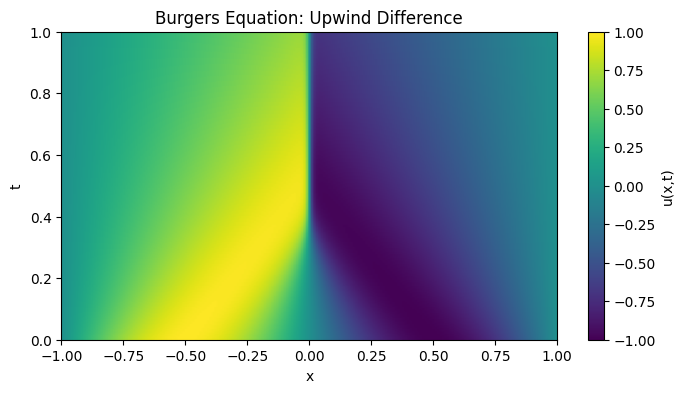

In [9]:
# -----------------------
# Heat-map style visualization: Upwind
# -----------------------

u_map_upwind = torch.stack(upwind_result["u_map_history"])

plt.figure(figsize=(8, 4))
plt.imshow(
    u_map_upwind.numpy(),
    extent=[x_min, x_max, upwind_result["t_map_history"][0], upwind_result["t_map_history"][-1]],
    aspect="auto",
    origin="lower",
)

plt.colorbar(label="u(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Burgers Equation: Upwind Difference")
plt.show()

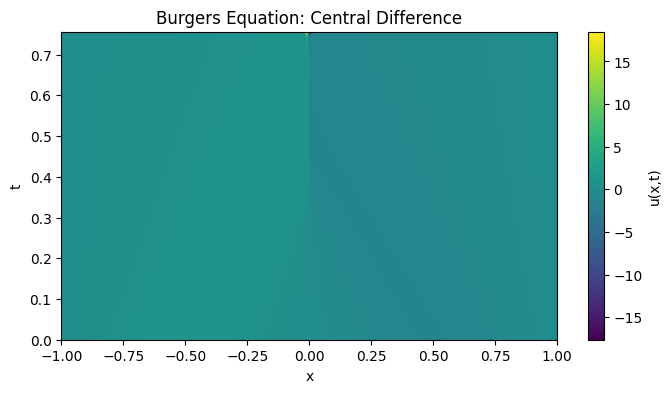

In [10]:
# -----------------------
# Heat-map style visualization: Central difference
# -----------------------

u_map_central = torch.stack(central_result["u_map_history"])

plt.figure(figsize=(8, 4))
plt.imshow(
    u_map_central.numpy(),
    extent=[x_min, x_max, central_result["t_map_history"][0], central_result["t_map_history"][-1]],
    aspect="auto",
    origin="lower",
)

plt.colorbar(label="u(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Burgers Equation: Central Difference")
plt.show()

## What to observe

Compared with the heat equation, Burgers equation has two effects:

- the nonlinear convection term $u\partial_x u$ moves and steepens the solution profile,
- the diffusion term $\nu\partial_{xx}u$ smooths the solution profile.

For the convection term:

- **upwind difference** follows the direction of information flow and is usually more stable,
- **central difference** is symmetric and simple, but it may create oscillations or become unstable when steep gradients form.

This is why the upwind method is often preferred for convection-dominated problems.